# Klasifikasi Kondisi Cuaca Berbasis Data Citra dan Data Meteorologi Menggunakan SVM dan RandomForest

*   Nasliyatul Intani (24031554097)
*   Elvira Rizki Berliananda Pamudji (24031554062)

Kelas 2024D Kelompok 5

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Load Data

In [ ]:
metadata = pd.read_csv("/content/drive/Shareddrives/PROJEK PM/complete_table_with_mcr.csv")
metadata.columns = metadata.columns.str.strip()
metadata = metadata.iloc[:1670]
print(metadata.shape)
metadata.head()

(1670, 87)


,Filename,CamId,Year,hoiem_MCR,hoiem_Accuracy,svetlana2010_MCR,svetlana2010_Accuracy,tcwc_MCR,tcwc_Accuracy,Date,...,ice,cluttered,soothing,stressful,exciting,sentimental,mysterious,boring,gloomy,lush
0,20130101_091628.jpg,10066,2013,0.100599,0.899401,0.083451,0.916549,0.352917,0.647083,735235.428102,...,0.201019,0.578970,0.175610,0.465193,0.115777,0.194916,0.091037,0.574105,0.475860,0.084300
1,20130101_114638.jpg,10066,2013,0.096901,0.903099,0.017214,0.982786,0.379089,0.620911,735235.532384,...,0.216055,0.620019,0.227166,0.327942,0.211095,0.264720,0.075191,0.467294,0.376086,0.124136
2,20130101_125725.jpg,10066,2013,0.107018,0.892982,0.075417,0.924583,0.467018,0.532982,735235.581539,...,0.172771,0.587002,0.290493,0.327276,0.248607,0.262659,0.165920,0.492840,0.335585,0.182317
3,20130101_154632.jpg,10066,2013,0.103177,0.896823,0.050664,0.949336,0.041107,0.958893,735235.698981,...,0.340141,0.560550,0.333954,0.403318,0.256928,0.242259,0.191882,0.447818,0.398973,0.158941
4,20130102_092726.jpg,10066,2013,0.076693,0.923307,0.099089,0.900911,0.074622,0.925378,735236.435718,...,0.661996,0.599993,0.269088,0.339950,0.205382,0.313981,0.353019,0.400919,0.289538,0.158939


In [ ]:
selected_columns = [
    'Filename',
    'Conds',
    'clouds',
    'Rain',
    'Snow',
    'Fog',
    'sunny',
    'TempM',
    'DewPtM',
    'Hum',
    'WspdM',
    'WgustM',
    'WDirD',
    'VisM',
    'PressureM',
    'WindChillM',
    'HeatIndexM',
    'PrecipM',
    'Month',
    'Day',
    'Hour'
]
metadata = metadata[selected_columns]
print(metadata.shape)
metadata.head()

(1670, 21)


,Filename,Conds,clouds,Rain,Snow,Fog,sunny,TempM,DewPtM,Hum,...,WgustM,WDirD,VisM,PressureM,WindChillM,HeatIndexM,PrecipM,Month,Day,Hour
0,20130101_091628.jpg,Clear,0.697720,0,0,0,0.000000,-3.0,-11.0,55.0,...,-9999.0,120.0,-9999.0,1014.0,-9.1,-9999.0,-9999.0,1,1,7
1,20130101_114638.jpg,Partly Cloudy,0.598105,0,0,0,0.043510,-3.0,-8.0,55.0,...,NaN,110.0,70.0,NaN,-999.0,-9999.0,NaN,1,1,16
2,20130101_125725.jpg,Clear,0.710545,0,0,0,0.075262,-2.0,-8.0,64.0,...,-9999.0,120.0,-9999.0,1012.0,-8.1,-9999.0,-9999.0,1,1,13
3,20130101_154632.jpg,Clear,0.498987,0,0,0,0.085147,-3.0,-8.0,69.0,...,-9999.0,110.0,-9999.0,1012.0,-7.6,-9999.0,-9999.0,1,1,15
4,20130102_092726.jpg,Light Snow,0.475156,0,1,1,0.134373,-4.0,-4.0,100.0,...,-9999.0,270.0,0.4,1014.0,-6.4,-9999.0,-9999.0,1,2,8


## Pengecekan dan Penanganan Missing Value

In [ ]:
print("Jumlah Missing Value:")
missing = metadata.isnull().sum()
print(missing)

Jumlah Missing Value:
Filename        0
Conds          54
clouds          0
Rain            0
Snow            0
Fog             0
sunny           0
TempM           0
DewPtM          0
Hum             0
WspdM           0
WgustM        448
WDirD           7
VisM            0
PressureM     448
WindChillM      0
HeatIndexM      0
PrecipM       448
Month           0
Day             0
Hour            0
dtype: int64


In [ ]:
metadata['Conds'] = metadata['Conds'].fillna('Unknown')

In [ ]:
metadata['PressureM'] = metadata['PressureM'].fillna(metadata['PressureM'].median())
metadata['WgustM'] = metadata['WgustM'].fillna(metadata['WgustM'].median())
metadata['PrecipM'] = metadata['PrecipM'].fillna(metadata['PrecipM'].median())
metadata['WDirD'] = metadata['WDirD'].fillna(metadata['WDirD'].median())

In [ ]:
missing = metadata.isnull().sum()
print(missing)

Filename      0
Conds         0
clouds        0
Rain          0
Snow          0
Fog           0
sunny         0
TempM         0
DewPtM        0
Hum           0
WspdM         0
WgustM        0
WDirD         0
VisM          0
PressureM     0
WindChillM    0
HeatIndexM    0
PrecipM       0
Month         0
Day           0
Hour          0
dtype: int64


## Pembentukan Label

In [ ]:
def create_label(row):
    cond = str(row['Conds']).lower()
    if 'snow' in cond:
        return 'snowy'
    elif 'rain' in cond or 'thunderstorm' in cond:
        return 'rainy'
    elif 'fog' in cond or 'mist' in cond:
        return 'foggy'
    elif cond in [
        'partly cloudy',
        'mostly cloudy',
        'scattered clouds',
        'overcast'
    ]:
        return 'cloudy'
    elif cond == 'clear':
        return 'sunny'
    else:
        return 'other'

metadata['label'] = metadata.apply(create_label, axis=1)
print(metadata['label'].value_counts())

label
cloudy    671
sunny     446
foggy     207
snowy     178
rainy     110
other      58
Name: count, dtype: int64


In [ ]:
metadata = metadata[metadata['label'] != 'other']
print(metadata['label'].value_counts())

label
cloudy    671
sunny     446
foggy     207
snowy     178
rainy     110
Name: count, dtype: int64


In [ ]:
image_folder = "/content/drive/Shareddrives/PROJEK PM/10066"
existing_files = set(os.listdir(image_folder))
metadata['exists'] = metadata['Filename'].isin(existing_files)
print(metadata['exists'].value_counts())

exists
True     1611
False       1
Name: count, dtype: int64


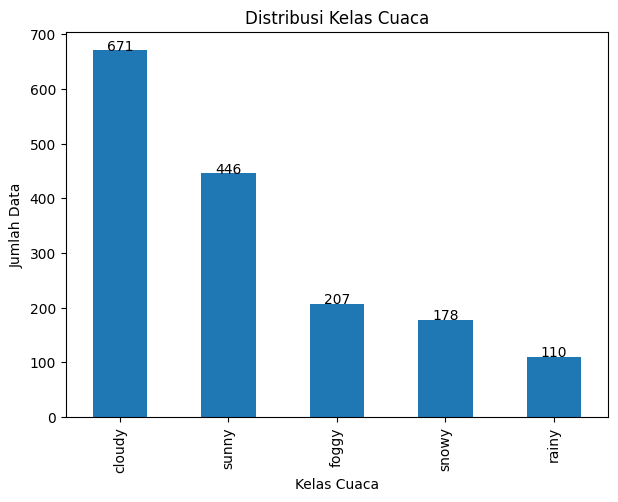

In [ ]:
plt.figure(figsize=(7,5))
value = metadata['label'].value_counts().plot(kind='bar')
for i in value.patches:
    value.text(
        i.get_x() + i.get_width()/2,
        i.get_height(),
        str(int(i.get_height())),
        ha='center'
    )
plt.title("Distribusi Kelas Cuaca")
plt.xlabel("Kelas Cuaca")
plt.ylabel("Jumlah Data")
plt.show()

In [ ]:
metadata_clean = metadata[metadata['exists'] == True].copy()

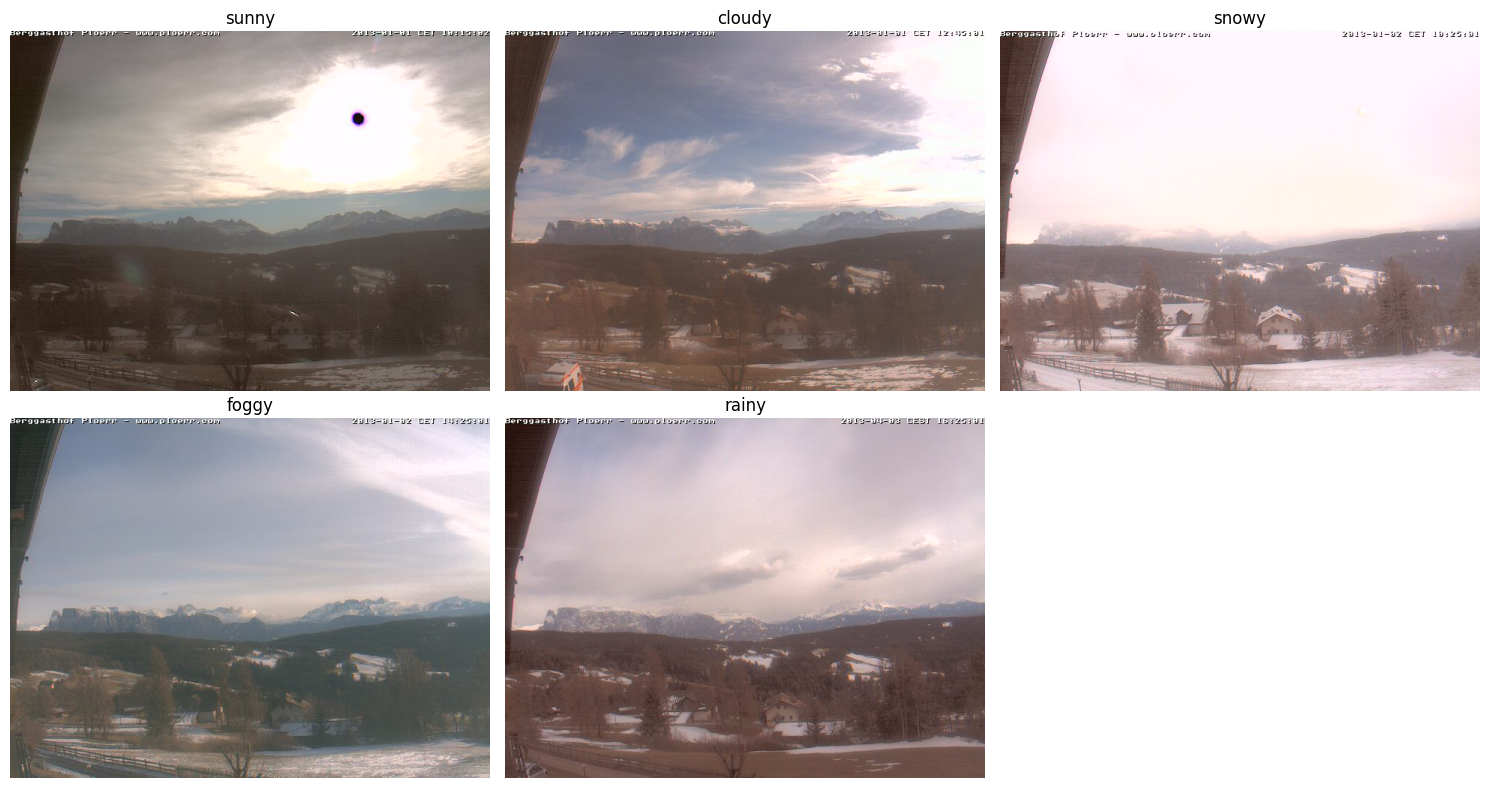

In [ ]:
classes = metadata_clean['label'].unique()
plt.figure(figsize=(15,8))
for i, label in enumerate(classes):
    sample = metadata_clean[metadata_clean['label'] == label].iloc[0]
    img_path = os.path.join(image_folder,sample['Filename'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Preprocessing Citra

In [ ]:
def preprocess_image(image):
    image = cv2.resize(image, (128, 128))
    return image

## Ekstraksi Fitur

In [ ]:
def extract_hsv(image, bins=(12,12,12)):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist(
        [hsv],
        [0,1,2],
        None,
        bins,
        [0,256,0,256,0,256]
    )

    hist = cv2.normalize(hist, hist).flatten()
    return hist

In [ ]:
def extract_lbp(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=16, R=2, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0,19),range=(0,18))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

In [ ]:
def extract_features(image, meteo_features=None, hsv_bins=(12,12,12)):
    hsv_feat = extract_hsv(image, bins=hsv_bins)
    lbp_feat = extract_lbp(image)
    if meteo_features is None:
        features = np.hstack([hsv_feat, lbp_feat])
    else:
        features = np.hstack([hsv_feat, lbp_feat, meteo_features])
    return features

## Input Data

In [ ]:
def build_dataset(metadata_clean, image_folder, meteorology_cols=None, hsv_bins=(12,12,12)):
    X = []
    y = []

    for _, row in metadata_clean.iterrows():
        filename = str(row['Filename']).strip()
        image_path = os.path.join(image_folder, filename)
        image = cv2.imread(image_path)
        if image is None:
            continue
        image = preprocess_image(image)
        if meteorology_cols is None:
            features = extract_features(image, None, hsv_bins)
        else:
            meteo_features = row[meteorology_cols].values.astype(float)

            features = extract_features(
                image,
                meteo_features,
                hsv_bins
            )

        X.append(features)
        y.append(row['label'])

    return np.array(X), np.array(y)

## Eksperimen

In [ ]:
def run_experiment(X, y, experiment_name):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm_model = SVC(kernel='rbf', C=10, gamma='scale')
    svm_model.fit(X_train_scaled, y_train)
    svm_pred = svm_model.predict(X_test_scaled)
    svm_acc = accuracy_score(y_test, svm_pred)

    rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    rf_acc = accuracy_score(y_test, rf_pred)

    return {
        'Experiment': experiment_name,
        'SVM': svm_acc,
        'RF': rf_acc
    }

### Variabel Meteorologi

In [ ]:
meteorology_cols = [
    'TempM',
    'DewPtM',
    'Hum',
    'WspdM',
    'WgustM',
    'WDirD',
    'VisM',
    'PressureM',
    'WindChillM',
    'HeatIndexM',
    'PrecipM',
    'Month',
    'Day',
    'Hour'
]

### Eksperimen 1 (HSV 12×12×12 + LBP)

In [ ]:
X1, y1 = build_dataset(
    metadata_clean,
    image_folder,
    meteorology_cols=None,
    hsv_bins=(12,12,12)
)

result1 = run_experiment(X1, y1, "HSV1728+LBP")

### Eksperimen 2 (HSV 8×8×8 + LBP)

In [ ]:
X2, y2 = build_dataset(
    metadata_clean,
    image_folder,
    meteorology_cols=None,
    hsv_bins=(8,8,8)
)

result2 = run_experiment(X2, y2, "HSV512+LBP")

### Eksperimen 3 (HSV 12×12×12 + LBP + Meteorologi)

In [ ]:
X3, y3 = build_dataset(
    metadata_clean,
    image_folder,
    meteorology_cols=meteorology_cols,
    hsv_bins=(12,12,12)
)

result3 = run_experiment(X3, y3, "HSV1728+LBP+Meteorology")

### Eksperimen 4 (HSV 8×8×8 + LBP + Meteorologi)

In [ ]:
X4, y4 = build_dataset(
    metadata_clean,
    image_folder,
    meteorology_cols=meteorology_cols,
    hsv_bins=(8,8,8)
)

result4 = run_experiment(X4, y4, "HSV512+LBP+Meteorology")

### Perbandingan

In [ ]:
comparison = pd.DataFrame([
    result1,
    result2,
    result3,
    result4
])
comparison

,Experiment,SVM,RF
0,HSV1728+LBP,0.495356,0.520124
1,HSV512+LBP,0.486068,0.529412
2,HSV1728+LBP+Meteorology,0.634675,0.693498
3,HSV512+LBP+Meteorology,0.671827,0.752322


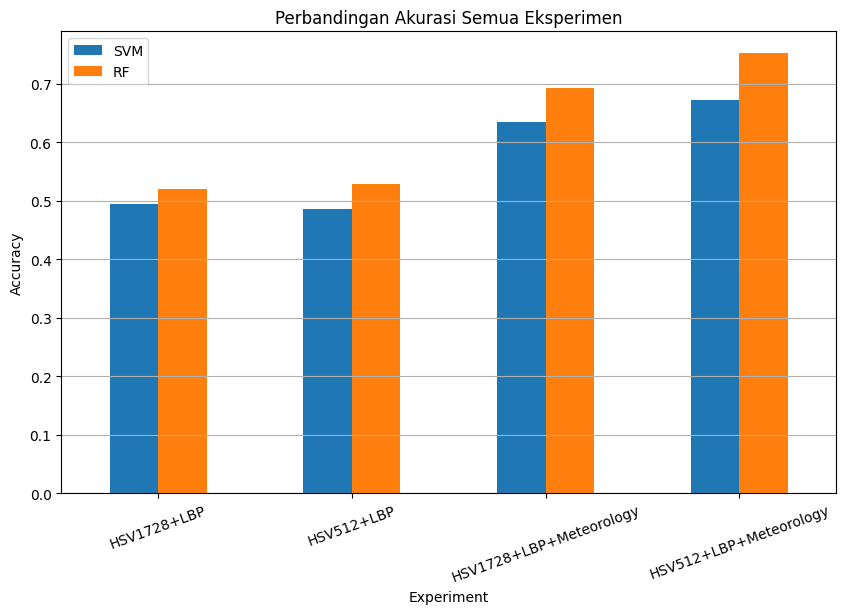

In [ ]:
comparison_plot = comparison.set_index('Experiment')
comparison_plot.plot(kind='bar', figsize=(10,6))

plt.title("Perbandingan Akurasi Semua Eksperimen")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.grid(axis='y')
plt.show()

## Evaluasi Model

In [ ]:
le = LabelEncoder()
y4_encoded = le.fit_transform(y4)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X4,
    y4_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y4_encoded
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### SVM

In [ ]:
svm_model = SVC(kernel='rbf', C=10, gamma='scale')
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("Model: SVM")
print("Classification Report SVM:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

Model: SVM
Classification Report SVM:
              precision    recall  f1-score   support

      cloudy       0.64      0.85      0.73       135
       foggy       0.32      0.24      0.28        41
       rainy       0.38      0.23      0.29        22
       snowy       0.60      0.50      0.55        36
       sunny       0.99      0.78      0.87        89

    accuracy                           0.67       323
   macro avg       0.59      0.52      0.54       323
weighted avg       0.67      0.67      0.66       323



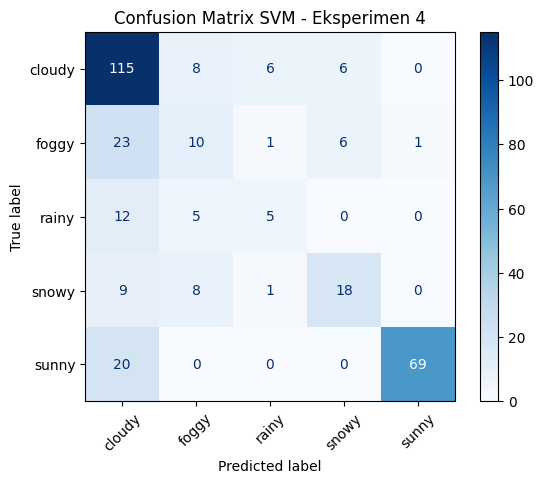

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)

plt.title("Confusion Matrix SVM - Eksperimen 4")
plt.show()

### Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Model: Random Forest")
print("Classification Report Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Model: Random Forest
Classification Report Random Forest
              precision    recall  f1-score   support

      cloudy       0.75      0.92      0.83       135
       foggy       0.48      0.32      0.38        41
       rainy       0.70      0.32      0.44        22
       snowy       0.63      0.61      0.62        36
       sunny       0.90      0.87      0.88        89

    accuracy                           0.75       323
   macro avg       0.69      0.61      0.63       323
weighted avg       0.74      0.75      0.74       323



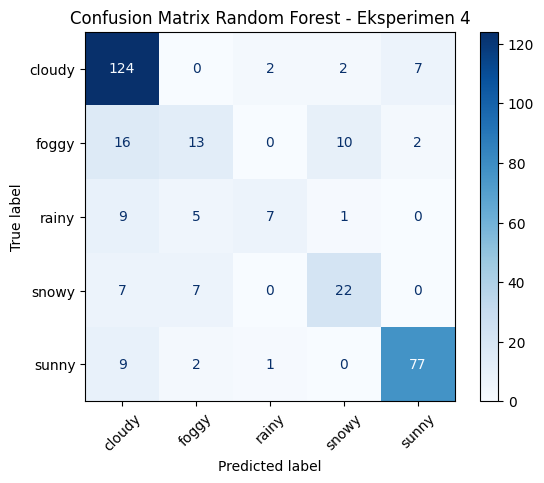

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)

plt.title("Confusion Matrix Random Forest - Eksperimen 4")
plt.show()

### Prediksi Gambar

Prediksi Gambar
Masukkan path gambar : /content/drive/Shareddrives/PROJEK PM/10066/20130114_095726.jpg


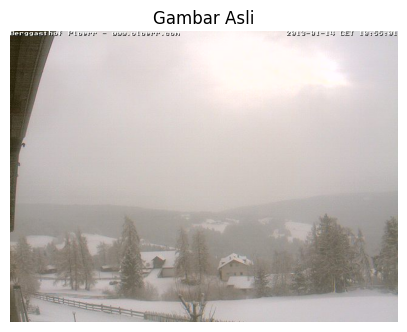

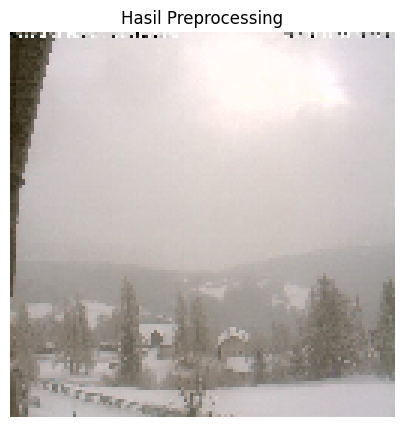

Prediksi Cuaca SVM         : foggy
Prediksi Cuaca RandomForest: foggy
Data Meteorologi
TempM        : -6.0
DewPtM       : -8.0
Hum          : 86.0
WspdM        : 5.6
WgustM       : -9999.0
WDirD        : 340.0
VisM         : 0.6
PressureM    : 999.0
WindChillM   : -8.7
HeatIndexM   : -9999.0
PrecipM      : -9999.0
Month        : 1
Day          : 14
Hour         : 10


In [ ]:
print("Prediksi Gambar")
test_image = input("Masukkan path gambar : ")
filename = os.path.basename(test_image)
image = cv2.imread(test_image)
if image is None:
    print("Gambar tidak ditemukan!")
else:
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Gambar Asli")
    plt.axis("off")
    plt.show()

    image_proc = preprocess_image(image)
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(image_proc, cv2.COLOR_BGR2RGB))
    plt.title("Hasil Preprocessing")
    plt.axis("off")
    plt.show()

    metadata_clean['Filename'] = metadata_clean['Filename'].astype(str)
    row_data = metadata_clean[metadata_clean['Filename'] == filename]
    if len(row_data) == 0:
        print("\nMetadata gambar tidak ditemukan!")
    else:
        row_data = row_data.iloc[0]
        meteo_features = row_data[meteorology_cols].values.astype(float)
        feature = extract_features(image_proc, meteo_features, hsv_bins=(8,8,8))
        feature = feature.reshape(1, -1)
        feature_scaled = scaler.transform(feature)
        svm_prediction = svm_model.predict(feature_scaled)
        rf_prediction = rf_model.predict(feature)
        svm_result = le.inverse_transform(svm_prediction)[0]
        rf_result = le.inverse_transform(rf_prediction)[0]

        print("Prediksi Cuaca SVM         :", svm_result)
        print("Prediksi Cuaca RandomForest:", rf_result)
        print("Data Meteorologi")
        for col in meteorology_cols:
            print(f"{col:12s} : {row_data[col]}")